In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [16]:
# 1. Load Dataset
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [17]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [19]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [20]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred = model.predict(X_test)

In [22]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
'''TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]'''
print(f"TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"Error Rate: {1 - accuracy_score(y_test, y_pred):.2f}")

TP: 24, FP: 3, TN: 65, FN: 8
Accuracy: 0.89
Precision: 0.89
Recall: 0.75
Error Rate: 0.11


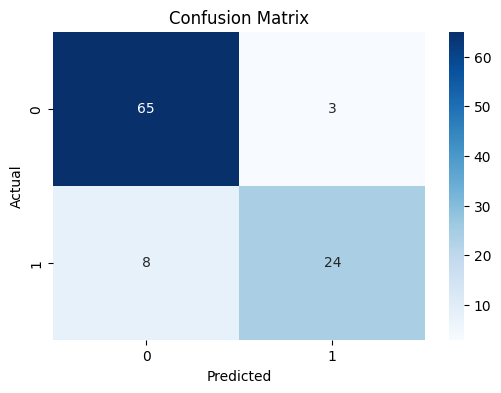

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(6, 4))

# 2. Create heatmap (simplified labels)
sns.heatmap(cm, annot=True, cmap='Blues')

# 3. Add Titles
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

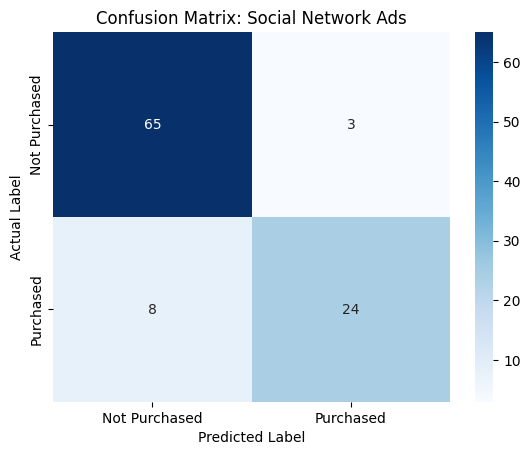

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Purchased', 'Purchased'], 
            yticklabels=['Not Purchased', 'Purchased'])

# Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Social Network Ads')
plt.show()

In [27]:
# 1. Define new data (Age, EstimatedSalary)
# Example: A 30-year-old making 50,000 and a 50-year-old making 100,000
new_data = pd.DataFrame({
    'Age': [30, 50],
    'EstimatedSalary': [50000, 100000]
})

# 2. Scale the new data using the SAME scaler (sc) used for training
# CRITICAL: Use .transform(), NOT .fit_transform()
#new_data_scaled = sc.transform(new_data)

# 3. Make predictions
new_predictions = model.predict(new_data_scaled)
new_probabilities = model.predict_proba(new_data_scaled)
print(new_predictions)

# 4. Display results
for i in range(len(new_data)):
    status = "Will Purchase" if new_predictions[i] == 1 else "Will Not Purchase"
    confidence = new_probabilities[i][new_predictions[i]] * 100
    print(f"User {i+1} (Age: {new_data.iloc[i]['Age']}, Salary: {new_data.iloc[i]['EstimatedSalary']}):")
    print(f" > Prediction: {status} ({confidence:.2f}% confidence)\n")

[0 1]
User 1 (Age: 30, Salary: 50000):
 > Prediction: Will Not Purchase (96.28% confidence)

User 2 (Age: 50, Salary: 100000):
 > Prediction: Will Purchase (92.19% confidence)



In [ ]:
'''
# --- EVALUATION METRICS FORMULAS ---

# Accuracy = (TP + TN) / (TP + TN + FP + FN)
# Measures the proportion of total predictions that were correct.

# Error Rate = (FP + FN) / (TP + TN + FP + FN)  OR  (1 - Accuracy)
# Measures the proportion of total predictions that were incorrect.

# Precision = TP / (TP + FP)
# Measures how many predicted positives were actually positive (Quality).

# Recall = TP / (TP + FN)
# Measures how many actual positives were correctly identified (Quantity).

# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
# The harmonic mean of Precision and Recall, useful for imbalanced classes.
'''